In [104]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import optimize
from Utils import *
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
#utils conversions and constants

deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s

G_cu = G * (1/AU_m)**3 * (M_sun) * (year)**2  
mu = G_cu

print(f"G in Canonical units: {G_cu} AU^3/ (M_sun year^2)")
print(f"mu in Canonical units: {mu} AU^3/year^2")

G in Canonical units: 39.48894168123623 AU^3/ (M_sun year^2)
mu in Canonical units: 39.48894168123623 AU^3/year^2


In [106]:
N = int(1e7)

file_state = f"state_vector_N{N}.dat"

if not os.path.isfile(file_state) or 0:
    print('Generating state vector')
    a_uniform = np.random.uniform(0, 2, N)
    e_uniform = np.random.uniform(0, 1, N)
    i_uniform = np.random.uniform(0, 2*np.pi, N)
    w_uniform = np.random.uniform(0, 2*np.pi, N)
    Omega_uniform = np.random.uniform(0, 2*np.pi, N)
    M_uniform = np.random.uniform(0, 2*np.pi, N)

    state_vector = np.zeros((N, 6))
    for element in tqdm(range(N)):
        a = a_uniform[element]
        e = e_uniform[element]
        i = i_uniform[element]
        Omega = Omega_uniform[element]
        w = w_uniform[element]
        M = M_uniform[element]
        q=a*(1-e)

        elements_spice = np.array([q, e, i, Omega, w, M, 0.0, mu])
        et = 0 
        state_vector_spice = spy.conics(elements_spice, et)
        state_vector[element] = state_vector_spice

    np.savetxt(file_state, state_vector)
else:
    print('state vector already generated')
    state_vector = np.loadtxt(file_state)

state vector already generated


In [107]:
xs = state_vector[:,0]
ys = state_vector[:,1]
zs = state_vector[:,2]
vxs = state_vector[:,3]
vys = state_vector[:,4]
vzs = state_vector[:,5]

x_cen = 1  #AU
y_cen = 0
z_cen = 0

delta_r = 0.1  #AU
dx = delta_r
dy = delta_r
dz = delta_r

vx_cen = 0
vy_cen = (mu/1)**0.5
vz_cen = 0

delta_v = (5000 * (1/AU_m) * year)  #AU/year
dvx = delta_v
dvy = delta_v
dvz = delta_v

In [108]:
objsx = (abs(xs - x_cen) <= dx) 
objsy = (abs(ys - y_cen) <= dy) 
objsz = (abs(zs - z_cen) <= dz) 
objsvx = (abs(vxs - vx_cen) <= dvx) 
objsvy = (abs(vys - vy_cen) <= dvy) 
objsvz = (abs(vzs - vz_cen) <= dvz) 

objects = objsx * objsy * objsz * objsvx * objsvy * objsvz
print(f'Number of objects inside volume: {objects.sum()}')

Number of objects inside volume: 372


In [109]:
condx = (xs<=x_cen+dx)*(xs>=x_cen-dx)
condy = (ys<=y_cen+dy)*(ys>=y_cen-dy)
condz = (zs<=z_cen+dz)*(zs>=z_cen-dz)
condvx = (vxs<=vx_cen+dvx)*(vxs>=vx_cen-dvx)
condvy = (vys<=vy_cen+dvy)*(vys>=vy_cen-dvy)
condvz = (vzs<=vz_cen+dvz)*(vzs>=vz_cen-dvz)

cond = condx * condy * condz * condvx * condvy * condvz
xsel = xs[cond]
ysel = ys[cond]
zsel = zs[cond]
vxs_sel = vxs[cond]
vys_sel = vys[cond]
vzs_sel = vzs[cond]

Nnum = cond.sum()
Nnum

np.int64(372)

In [110]:
state_vectors = np.column_stack((xsel, ysel, zsel, vxs_sel, vys_sel, vzs_sel))

X = state_vectors[0]
X

array([ 0.93335799, -0.03731348, -0.05490629, -0.70230105,  6.68410618,
       -0.31041888])

In [111]:
E = spy.oscelt(X, et=0, mu=mu)
E

array([ 0.84927131,  0.15830113,  0.08048616,  2.28517061,  5.20049225,
        5.32968218,  0.        , 39.48894168])

In [112]:
E = E[:6]
JXoE = calcKeplerianJacobians(mu,E,X)
JXoE

array([[ 0.9250358 , -0.39439119, -0.04148188,  0.03731348,  0.03430059,
        -0.11327136],
       [-0.03698077, -1.8454397 , -0.03597157,  0.93335799,  0.93367158,
         1.0780531 ],
       [-0.05441672,  0.12155475, -0.68070933,  0.        , -0.05142942,
        -0.05006624],
       [ 0.34801953,  6.56204349, -0.2345225 , -6.68410618, -6.67881872,
        -7.25585533],
       [-3.31225403,  2.86989275, -0.20336932, -0.70230105, -0.68117208,
         0.29007217],
       [ 0.15382553, -0.55154302, -3.84846674,  0.        ,  0.44299792,
         0.4268374 ]])

In [113]:
det = np.abs(np.linalg.det(np.linalg.inv(JXoE)))
det

np.float64(0.6304283144749208)

In [114]:
a_min = 0 #au
a_max = 2 #au
e_min = 0
e_max = 1
i_min = 0 #rad
i_max = np.pi #rad
Omega_min = 0 #rad
Omega_max = 2*np.pi #rad
w_min = 0 #rad
w_max = 2*np.pi #rad
E_min = 0 #rad
E_max = 2*np.pi #rad

p_E = p_E_uniform(a_min, a_max, e_min, e_max, i_min, i_max, Omega_min, Omega_max, w_min, w_max, E_min, E_max)

print(f'Probability uniform distribution for orbital elements: ', p_E)

Probability uniform distribution for orbital elements:  0.000641623890917771


In [115]:
Delta = (2*dx) * (2*dy) * (2*dz) * (2*dvx) * (2*dvy) * (2*dvz)
n = N * p_E * det * Delta
n

np.float64(303.75493650834835)

### Calculo usando deirvada numerica

In [116]:
def X2E(X,mu):
    elts=spy.oscelt(X,0,mu)
    E=elts[:6]
    return E

dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JEoX_num=computeNumericalJacobian(X2E,X,dX,**args)
det = np.linalg.det(JEoX_num)

Delta = (2*dx) * (2*dy) * (2*dz) * (2*dvx) * (2*dvy) * (2*dvz)
n_numerical = N * p_E * det * Delta

In [117]:
print("Conteo de objetos dentro de la caja: ", objects.sum())
print("Numero de objetos calculados dentro de la caja: ", n)
print("Numero de objetos calculados derivada numerica: ", n_numerical)

Conteo de objetos dentro de la caja:  372
Numero de objetos calculados dentro de la caja:  303.75493650834835
Numero de objetos calculados derivada numerica:  255.67744916921603


In [145]:
def X_in_box(N: int, center_r: tuple, center_v: tuple, delta_r: float, delta_v: float, state_vector = None) -> tuple:
    #genero un muestreo de puntos en el espacio esferico

    if state_vector is None:
        print('Generating state vector')
        file_state = f"state_vector_N{N}.dat"

        if not os.path.isfile(file_state) or 0:
            print('Generating state vector')
            a_uniform = np.random.uniform(0, 2, N)
            e_uniform = np.random.uniform(0, 1, N)
            i_uniform = np.random.uniform(0, 2*np.pi, N)
            w_uniform = np.random.uniform(0, 2*np.pi, N)
            Omega_uniform = np.random.uniform(0, 2*np.pi, N)
            M_uniform = np.random.uniform(0, 2*np.pi, N)

            state_vector = np.zeros((N, 6))
            for element in tqdm(range(N)):
                a = a_uniform[element]
                e = e_uniform[element]
                i = i_uniform[element]
                Omega = Omega_uniform[element]
                w = w_uniform[element]
                M = M_uniform[element]
                q=a*(1-e)

                elements_spice = np.array([q, e, i, Omega, w, M, 0.0, mu])
                et = 0 
                state_vector_spice = spy.conics(elements_spice, et)
                state_vector[element] = state_vector_spice

            np.savetxt(file_state, state_vector)
        else:
            print('state vector already generated')
            state_vector = np.loadtxt(file_state)
            print('state vector loaded')

    #trasnformo a espacio cartesiano
    x_uniform = state_vector[:,0]
    y_uniform = state_vector[:,1]
    z_uniform = state_vector[:,2]
    vx_uniform = state_vector[:,3]
    vy_uniform = state_vector[:,4]
    vz_uniform = state_vector[:,5]

    delta_x = delta_r
    delta_y = delta_r
    delta_z = delta_r

    delta_vx = delta_v
    delta_vy = delta_v
    delta_vz = delta_v

    #masking para obtener los objetos dentro de la caja
    objsx = (abs(x_uniform - center_r[0]) <= delta_x) 
    objsy = (abs(y_uniform - center_r[1]) <= delta_y) 
    objsz = (abs(z_uniform - center_r[2]) <= delta_z) 
    
    objsvx = (abs(vx_uniform - center_v[0]) <= delta_vx) 
    objsvy = (abs(vy_uniform - center_v[1]) <= delta_vy) 
    objsvz = (abs(vz_uniform - center_v[2]) <= delta_vz) 

    objects = objsx * objsy * objsz * objsvx * objsvy * objsvz

    x_in_box = x_uniform[objects]
    y_in_box = y_uniform[objects]
    z_in_box = z_uniform[objects]
    vx_in_box = vx_uniform[objects]
    vy_in_box = vy_uniform[objects]
    vz_in_box = vz_uniform[objects]

    return x_in_box[0], y_in_box[0], z_in_box[0], vx_in_box[0], vy_in_box[0], vz_in_box[0], objects.sum(), state_vector

In [146]:
def N_theoric(E: np.array, X: np.array, delta_r: float, delta_v: float, N: int, p_E: float) -> float:
    JXoE = calcKeplerianJacobians(mu,E,X)
    det = np.abs(np.linalg.det(np.linalg.inv(JXoE)))

    delta_x = delta_r
    delta_y = delta_r
    delta_z = delta_r

    delta_vx = delta_v
    delta_vy = delta_v
    delta_vz = delta_v
    
    Delta = (2*delta_x) * (2*delta_y) * (2*delta_z) * (2*delta_vx) * (2*delta_vy) * (2*delta_vz)
    p_X = N * Delta * det * p_E
    return p_X

In [151]:
x_cen = 1  #AU
y_cen = 0
z_cen = 0
center_r = (x_cen, y_cen, z_cen)
delta_r = 0.05  #AU

vx_cen = 0
vy_cen = (mu/1)**0.5
vz_cen = 0
center_v = (vx_cen, vy_cen, vz_cen)
delta_v = (1000 * (1/AU_m) * year)  #AU/year

N = int(1e8)
state_vector = None if state_vector is None else state_vector

output = X_in_box(N, center_r, center_v, delta_r, delta_v, state_vector)
state_vector = output[-1]
num = output[-2]
X = output[:6]
E_selected = spy.oscelt(X, et=0, mu=mu)
E = E_selected[:6]

num_theoric = N_theoric(E, X, delta_r, delta_v, N, p_E)

print('Numero de objetos en la caja: ', num)
print('Numero de objetos teórico: ', num_theoric)

Numero de objetos en la caja:  43
Numero de objetos teórico:  174.05928078872037


In [ ]:
obj_in_box = objects.sum()
total_objects = np.linspace(0, 50, 50)

objs = []
for obj in tqdm(state_vectors[:50]):
    X = obj
    E = spy.oscelt(X, et=0, mu=mu)
    objs.append(N_theoric(E[:6], X, delta_r, delta_v, N, p_E))

100%|██████████| 50/50 [00:00<00:00, 11567.94it/s]


In [141]:
N = int(1e8)

x_cen = 1 #AU
y_cen = 0
z_cen = 0
center_r = (x_cen, y_cen, z_cen)
deltas_r = np.linspace(0.01, 0.05, 5)

vx_cen = 0
vy_cen = (mu/1)**0.5
vz_cen = 0
center_v = (vx_cen, vy_cen, vz_cen)
delta_v = (1000 * (1/AU_m) * year)  #AU/year

n_size = []
N_size = []
state_vector = None if state_vector is None else state_vector
print(type(state_vector))
for deltas in tqdm(deltas_r):
    delta_r = deltas
    output = X_in_box(N, center_r, center_v, delta_r, delta_v, state_vector)
    state_vector = output[-1]
    num = output[-2]
    n_size.append(num)

    X = output[:6]

    E_selected = spy.oscelt(X, et=0, mu=mu)
    E = E_selected[:6]

    N_size.append(N_theoric(E, X, delta_r, delta_v, N, p_E))

<class 'numpy.ndarray'>


100%|██████████| 5/5 [00:29<00:00,  5.85s/it]


In [139]:
state_vector

array([[-0.40595751, -0.54605137, -0.40531802,  3.19632734, -1.1950685 ,
        -6.16572945],
       [ 0.03181708,  1.10535452,  0.22687246, -3.09328008, -2.40188736,
         5.50952744],
       [-0.01942426, -0.14019779, -0.28246791,  0.60527281,  7.6759661 ,
        12.25627549],
       ...,
       [ 1.85632302, -0.73460863, -0.46220131,  1.86307423,  3.31543758,
        -1.34266731],
       [ 0.70876312,  0.36811929,  0.29243071, -2.57651748,  6.29320845,
        -0.01697366],
       [-1.20240298,  0.72364986, -0.55580532, -4.64275263, -1.32160345,
        -0.2755162 ]], shape=(100000000, 6))

In [ ]:
N = int(1e7)

centers_r = np.linspace(0., 0.5, 10)
delta_r = 0.1

n_center = []
N_center = []
for c in tqdm(centers_r):
    center_r = (c,c,c)

    X_selected = X_in_box(N, center_r, center_v, delta_r, delta_v)
    num = X_selected[-1]
    n_center.append(num)

    X = X_selected[:6]

    E_selected = spy.oscelt(X, et=0, mu=mu)
    E = E_selected[:6]

    N_center.append(N_theoric(E, X, delta_r, delta_v, N, p_E))

  0%|          | 0/10 [00:00<?, ?it/s]

state vector already generated


 10%|█         | 1/10 [00:20<03:06, 20.76s/it]

state vector already generated


 20%|██        | 2/10 [00:40<02:41, 20.15s/it]

...

 80%|████████  | 8/10 [23:10<03:46, 113.24s/it]

state vector already generated


 90%|█████████ | 9/10 [23:28<01:23, 83.27s/it] 

state vector already generated


100%|██████████| 10/10 [23:45<00:00, 142.53s/it]


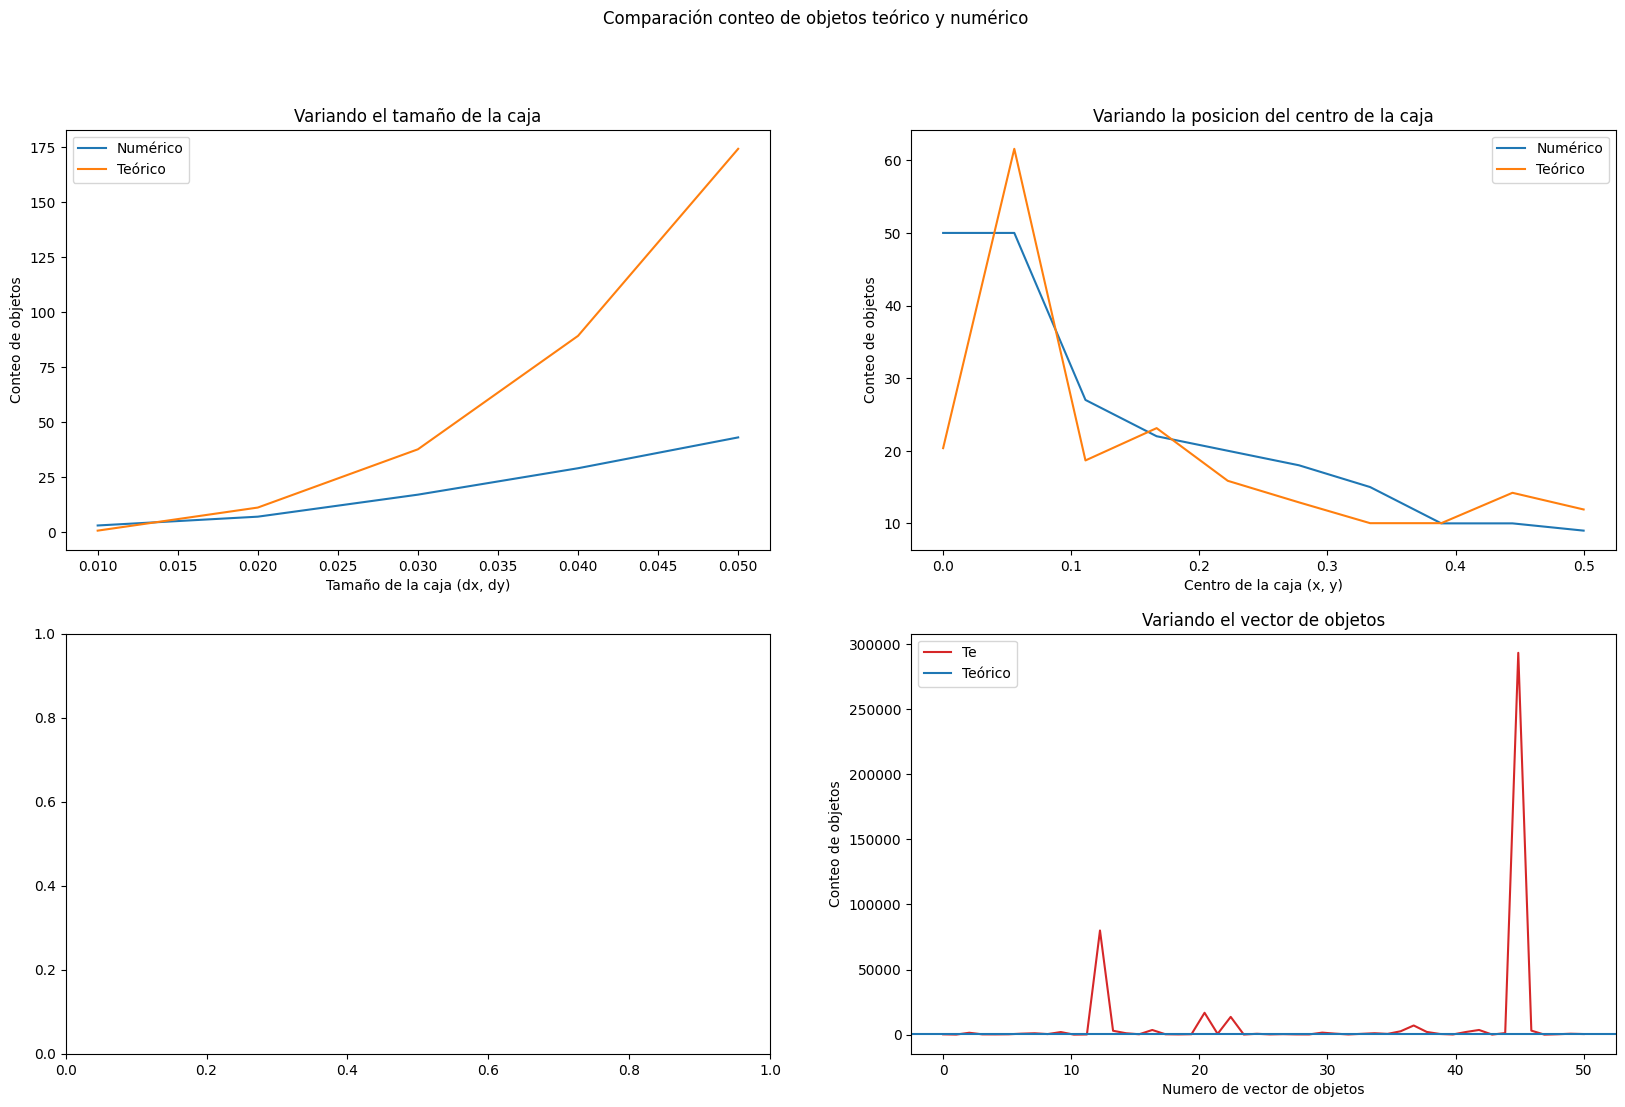

In [142]:
fig, axs = plt.subplots(2, 2, figsize=(20,12))
axs[0, 0].plot(deltas_r, n_size, label='Numérico')
axs[0, 0].plot(deltas_r, N_size, label='Teórico')
axs[0, 0].set_title('Variando el tamaño de la caja')
axs[0, 0].set_xlabel('Tamaño de la caja (dx, dy)')
axs[0, 0].set_ylabel('Conteo de objetos')
axs[0, 0].legend()

axs[0, 1].plot(centers_r, n_center, label='Numérico')
axs[0, 1].plot(centers_r, N_center, label='Teórico')
axs[0, 1].set_xlabel('Centro de la caja (x, y)')
axs[0, 1].set_ylabel('Conteo de objetos')
axs[0, 1].set_title('Variando la posicion del centro de la caja')
axs[0, 1].legend()      

axs[1, 1].plot(total_objects, objs, 'tab:red', label='Te')
axs[1, 1].axhline(obj_in_box, label='Teórico')
axs[1, 1].set_xlabel('Numero de vector de objetos')
axs[1, 1].set_ylabel('Conteo de objetos')
axs[1, 1].set_title('Variando el vector de objetos')
axs[1, 1].legend()

plt.suptitle("Comparación conteo de objetos teórico y numérico")
plt.show();